In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # c:\university_chatbot
sys.path.insert(0, str(PROJECT_ROOT))

from src.agent.graph import create_agent_graph
from IPython.display import Image, display

c:\university_chatbot\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
USER_AGENT environment variable not set, consider setting it to identify your requests.


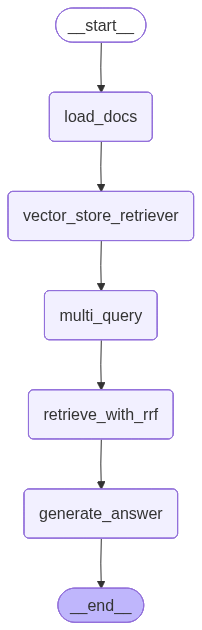

In [2]:
agent_graph = create_agent_graph()

display(Image(agent_graph.get_graph().draw_mermaid_png()))

In [4]:
from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages

from typing_extensions import TypedDict, Annotated, Any, List
from langchain_core.documents import Document

class State(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]

    query: str
    queries: List[str]
    path_to_docs: str

    chunk_size: int
    chunk_overlap: int

    embed_model: str
    main_model: str
    llm: Any

    top_k_docs: int
    top_k_queries: int

    raw_docs: List[Document]
    split_docs: List[Document]
    retrieved_docs: str

    final_answer: str

init_state: State = {
    "messages": [],

    "query": "Điều kiện để được xét công nhận tốt nghiệp chương trình Đại Học là gì?",
    "queries": [],
    "path_to_docs": "../data/raw_documents",

    "chunk_size": 500,
    "chunk_overlap": 50,

    "embed_model": "mxbai-embed-large",
    "main_model": "llama3:8b",

    "top_k_docs": 5,
    "top_k_queries": 5,

    "raw_docs": [],
    "split_docs": [],
    "retrieved_docs": "",

    "final_answer": "",
}

graph = create_agent_graph()
final_state = graph.invoke(init_state)

print(f"Final Answer: {final_state['final_answer']}")

Final Answer: answer='Điều kiện để được xét công nhận tốt nghiệp chương trình Đại học là phải đáp ứng toàn bộ điều kiện tốt nghiệp của chương trình, bao gồm: hoàn thành tất cả học phần trong danh mục quy định; có thành tích học tập xuất sắc và có tiềm năng nghiên cứu. Ngoài ra, người học cũng phải nộp đơn đề nghị trở lại học chậm nhất 01 tuần trước khi bắt đầu học kỳ mới và tuân theo kế hoạch học tập chuẩn toàn khóa của chương trình.'


In [5]:
final_state["queries"]

['Điều kiện gì về điểm trung bình chung để được xét công nhận tốt nghiệp chương trình Đại Học?',
 'Các điều kiện gì về học kỳ, như số lượng tín chỉ hay GPA, để được xét công nhận tốt nghiệp chương trình Đại Học?',
 'Điều kiện gì về các hoạt động ngoại khóa, như tham gia nghiên cứu khoa học hay tình nguyện, để được xét công nhận tốt nghiệp chương trình Đại Học?',
 'Điều kiện gì về luận văn tốt nghiệp, như nội dung và độ dài, để được xét công nhận tốt nghiệp chương trình Đại Học?',
 'Các điều kiện gì về thời gian, như hạn chót nộp luận văn hay tham gia các hoạt động ngoại khóa, để được xét công nhận tốt nghiệp chương trình Đại Học?']

In [6]:
final_state["retriever"]

VectorStoreRetriever(tags=['Chroma', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000002878091D010>, search_kwargs={'k': 5})

In [7]:
final_state["retrieved_docs"]

'Nội dung của tài liệu 1: chọn như sau: \na) Nhóm học phần bắt buộc: người học phải hoàn thành tất cả học phần trong danh \nmục quy định.  \nb) Nhóm học phần tự chọn theo mô đun: người học chọn một định hướng chuyên \nmôn và phải hoàn thành tất cả học phần trong danh mục của nhóm học phần tự chọn theo \nmô đun. \nc) Nhóm học phần tự chọn: người học chọn lựa một số học phần trong danh mục để \ntích lũy đủ số TC quy định. \n5. Học phần tương đương và học phần thay thế \na) Hai học phần được coi là tương đương khi có nội dung chuyên môn trùng lặp tối \nthiểu 70%. Trong trường hợp cần thiết, người học được tùy chọn học một học phần tương \nđương để lấy kết quả thay cho một học phần yêu cầu trong CTĐT, tuy nhiên cần đảm bảo \nsố tín chỉ của học phần tương đương tối thiểu bằng hoặc lớn hơn số tín chỉ của học phần \nyêu cầu trong CTĐT. Quy định này áp dụng cho cả trường hợp người học mong muốn học \ncải thiện điểm trung bình tích lũy. \nb) Người học được phép học một học phần thay thế được tr

In [8]:
final_state["final_answer"]

GenerateAnswerSchema(answer='Điều kiện để được xét công nhận tốt nghiệp chương trình Đại học là phải đáp ứng toàn bộ điều kiện tốt nghiệp của chương trình, bao gồm: hoàn thành tất cả học phần trong danh mục quy định; có thành tích học tập xuất sắc và có tiềm năng nghiên cứu. Ngoài ra, người học cũng phải nộp đơn đề nghị trở lại học chậm nhất 01 tuần trước khi bắt đầu học kỳ mới và tuân theo kế hoạch học tập chuẩn toàn khóa của chương trình.')